# Walk Forward Validation Analysis and Model Selection
In this notebook, we explore the results of the walk-forward validation experiment, portfolio performances. Eventually, these are used to selected models that will be passed on to the testing stage on completely unseen data with no look ahead bias.

### Setup:

In [1]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.evaluation.evaluator import Evaluator
from src.utils.io import load_path_config
from src.data_processing.loading import load_csv_files, ArtifactDataExtractor
from src.evaluation.selection import filter_models
from sklearn.decomposition import PCA
from src.utils.formatting import deserialize_np_dict
from src.utils.window import calc_current_idxs, get_date_index_col
from sklearn.preprocessing import StandardScaler
from src.visualization.plots import plot_windowed_comparison, plot_corr, plot_3d_pareto, plot_2d_pareto, plot_2d_pareto_diff_colrs
from src.evaluation.selection import high_corr_with_each_metric, pareto_dominance
from src.utils.constants import EQ_WT_NAME, SP500_NAME

from src.models.registry import TradModelLibrary, NNModelLibrary
from src.evaluation.metrics import MetricLibrary

import re

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

In [3]:

grid_mode = 'one_model'
model_name = None
loss_name = None # Change previous grid mode if needed

extractor = ArtifactDataExtractor(grid_mode, artifacts_paths)

if grid_mode == 'one_model':
    # Get all models from library
    all_models = []
    for cat in NNModelLibrary.list_categories():
        all_models.extend(NNModelLibrary.list_models(cat))

    all_avg_perf = extractor.agg_avg_perf('avg_perf', all_models)
    opti_hparams = extractor.agg_opti_hparams('optimized', all_models)
    all_daily_rets = extractor.agg_daily_rets('daily_rets', all_models)
    
elif grid_mode == 'one' and model_name is not None and loss_name is not None:
    opti_hparams = extractor.agg_opti_hparams(
        'optimized', [f'{model_name}-{loss_name}']
    )
    filtered_models = None

#### Removing custom losses 13 and 14
This is done because there was a bug in the loss functions of 13 and 14 and rerunning would be very expensive. Will be fixed soon

In [4]:
mask = all_avg_perf.index.str.contains('-custom_loss_13|-custom_loss_14')
all_avg_perf = all_avg_perf[~mask]

pattern = re.compile(r'custom_loss_(13|14)')
opti_hparams = {k: v for k, v in opti_hparams.items() if not pattern.search(k)}

all_daily_rets = {k: v for k, v in all_daily_rets.items() if not pattern.search(k)}

#### Average Portfolio Performances
This is the average of portfolio metrics over all windows of walk steps. It is not the performances of the models over the entire validation period of 2 years.

In [4]:
# all_benches = TradModelLibrary.list_models()
all_benches = [EQ_WT_NAME, SP500_NAME]

# Filter models that beat Equal Weight Portfolio
filtered_perf, filtered_models = filter_models(
    all_avg_perf, EQ_WT_NAME, 'sharpe', all_benches
)

print(f'\n {len(filtered_models)} Models beat Equal Weight portfolio.')
# print('Filtered Avg. Performance Metrics: \n', filtered_perf)
filtered_perf = filtered_perf.sort_values(by='sharpe', ascending=False)
filtered_perf


 8 Models beat Equal Weight portfolio.


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_11,0.066037,0.131950,0.203725,-0.093162,-0.030375,1.444662,0.025063
AttentionLSTM-custom_loss_10,0.114550,0.123125,0.187537,-0.104262,-0.035888,1.426862,0.025837
VLSTM-custom_loss_11,0.062475,0.119075,0.165538,-0.090912,-0.031500,1.404637,0.024012
InvertedAttentionLSTM-custom_loss_11,0.078588,0.115737,0.183000,-0.099637,-0.033350,1.370062,0.023175
BaseLSTM-custom_loss_10,0.097625,0.114288,0.177725,-0.084487,-0.029875,1.384963,0.024225
DeformTime-custom_loss_15,0.059500,0.111725,0.165950,-0.100325,-0.031100,1.349875,0.019262
TemporalTransformer-custom_loss_16,0.056400,0.108300,0.169250,-0.082000,-0.025725,1.360663,0.023838
BaseLSTM-custom_loss_16,0.060662,0.108175,0.165650,-0.098000,-0.032662,1.372187,0.022450
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125


In [5]:
all_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_10,0.036825,0.080613,0.120887,-0.107012,-0.031988,1.254675,0.014200
DeformTime-custom_loss_11,0.066037,0.131950,0.203725,-0.093162,-0.030375,1.444662,0.025063
DeformTime-custom_loss_15,0.059500,0.111725,0.165950,-0.100325,-0.031100,1.349875,0.019262
DeformTime-custom_loss_16,0.098637,0.106850,0.170100,-0.108650,-0.040425,1.331112,0.021138
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125
TemporalTransformer-custom_loss_10,0.056200,0.086125,0.151150,-0.133137,-0.040712,1.319587,0.026225
TemporalTransformer-custom_loss_11,0.007638,0.006575,0.012187,-0.122887,-0.034825,1.104675,0.007537
TemporalTransformer-custom_loss_15,0.048837,0.063963,0.101675,-0.108200,-0.030225,1.247550,0.016362
TemporalTransformer-custom_loss_16,0.056400,0.108300,0.169250,-0.082000,-0.025725,1.360663,0.023838


### Mean Sharpe Analysis - Overall View

Models/Approaches that BEAT Equal Weight Mean Sharpe:


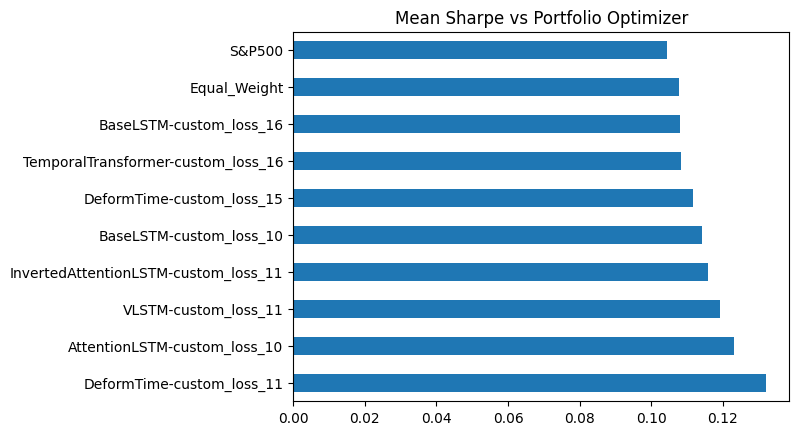

In [6]:
filtered_perf['sharpe'].plot.barh(title='Mean Sharpe vs Portfolio Optimizer')
print('Models/Approaches that BEAT Equal Weight Mean Sharpe:')

In [7]:
print('Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:')
no_beat = all_avg_perf.drop(filtered_perf.index, axis=0)
print(f'{len(no_beat)} NN models did not beat Equal Weight Portfolio:')
no_beat

Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:
20 NN models did not beat Equal Weight Portfolio:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_10,0.036825,0.080613,0.120887,-0.107012,-0.031988,1.254675,0.014200
DeformTime-custom_loss_16,0.098637,0.106850,0.170100,-0.108650,-0.040425,1.331112,0.021138
TemporalTransformer-custom_loss_10,0.056200,0.086125,0.151150,-0.133137,-0.040712,1.319587,0.026225
TemporalTransformer-custom_loss_11,0.007638,0.006575,0.012187,-0.122887,-0.034825,1.104675,0.007537
TemporalTransformer-custom_loss_15,0.048837,0.063963,0.101675,-0.108200,-0.030225,1.247550,0.016362
PatchTST-custom_loss_10,0.029913,0.021888,0.038462,-0.101600,-0.030588,1.111512,0.008863
PatchTST-custom_loss_11,0.049662,0.073450,0.127925,-0.136838,-0.038800,1.269362,0.018725
PatchTST-custom_loss_15,0.070875,0.076675,0.112750,-0.088812,-0.030937,1.285275,0.017937
PatchTST-custom_loss_16,-0.004112,0.015287,0.031350,-0.116262,-0.031125,1.115450,0.008887
BaseLSTM-custom_loss_11,0.063437,0.086712,0.132013,-0.101862,-0.033763,1.295675,0.017700


#### Models Portfolio Performances
This is the performance of each portfolio for the entire validation period

In [8]:
metrics_to_ann = ['sharpe', 'sortino', 'calmar']

evaluator = Evaluator(
    eval_returns=None,
    ba_eval=None,
    all_daily_returns=deserialize_np_dict(all_daily_rets), # Deserialize dict: replace lists with np.array()
    metrics_lib=MetricLibrary.items()
)

all_overall_perfs = evaluator.calc_pf_performances(metrics_to_ann)

all_overall_perfs['compunded_return'] = all_overall_perfs['compunded_return']*100
all_overall_perfs['max_drawdown'] = all_overall_perfs['max_drawdown']*100
all_overall_perfs['cvar'] = all_overall_perfs['cvar']*100

all_overall_perfs = all_overall_perfs.sort_values(by='sharpe', ascending=False)
all_overall_perfs

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
BaseLSTM-custom_loss_10,105.34,1.6740,2.3681,-19.08,-3.42,1.3379,2.4053
AttentionLSTM-custom_loss_10,132.13,1.5546,2.0459,-31.54,-4.54,1.3519,1.7631
InvertedAttentionLSTM-custom_loss_10,91.27,1.5189,2.3667,-13.05,-3.18,1.3318,3.1082
DeformTime-custom_loss_16,109.57,1.4018,1.9070,-26.87,-4.43,1.2876,1.7665
InvertedAttentionLSTM-custom_loss_11,79.32,1.2538,1.5463,-36.76,-4.04,1.2654,0.9761
PatchTST-custom_loss_15,67.71,1.1199,1.4971,-29.21,-4.00,1.2516,1.0676
InvertedAttentionLSTM-custom_loss_15,65.40,1.0794,1.2787,-37.31,-4.32,1.2362,0.8104
DeformTime-custom_loss_11,61.10,1.0706,1.1768,-36.01,-4.24,1.2527,0.7899
VLSTM-custom_loss_11,57.50,1.0645,1.2065,-34.00,-3.91,1.2351,0.7920
TemporalTransformer-custom_loss_16,51.00,1.0594,1.2722,-31.09,-3.45,1.2318,0.7770


#### Fixing Spelling Errors
compunded_returns -> comp_returns

max_drawdown -> mdd

In [9]:
all_overall_perfs = all_overall_perfs.rename(columns={"compunded_return": "comp_return", "max_drawdown": "mdd"})

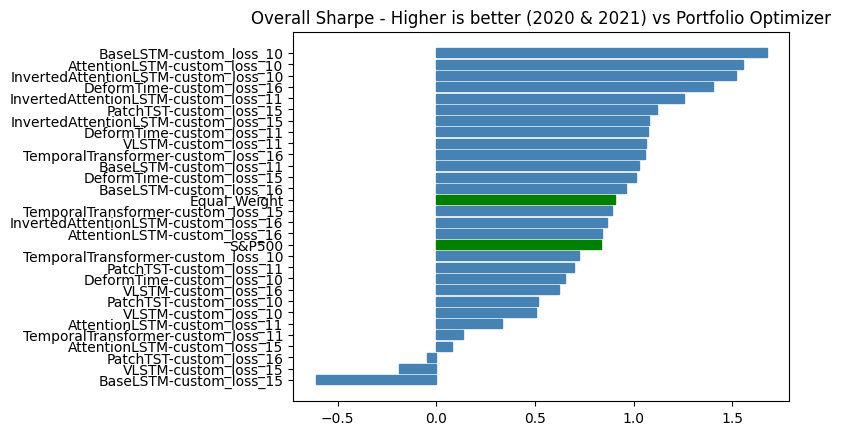

In [10]:
# all_overall_perfs['sharpe'].plot.barh(
#     title='Overall Sharpe (2020 & 2021) vs Portfolio Optimizer', color={'Equal_Weight': 'green', 'S&P500': 'green'}
# )
 
temp_perfs = all_overall_perfs.sort_values(by='sharpe', ascending=True)
fig, ax = plt.subplots()
bars = ax.barh(temp_perfs.index, temp_perfs['sharpe'])
for bar, idx in zip(bars, temp_perfs.index):
    if idx in ['Equal_Weight', 'S&P500']:
        bar.set_color('green')
    else:
        bar.set_color('steelblue')
ax.set_title('Overall Sharpe - Higher is better (2020 & 2021) vs Portfolio Optimizer')
plt.show()

In [11]:
# Split Benchmarks and filtered models
benchmarks_df = all_overall_perfs[all_overall_perfs.index.isin(all_benches)]
all_overall_perfs = all_overall_perfs[~all_overall_perfs.index.isin(all_benches)]

##### *NOTE:* From here onwards we use the dataframe consisting of overall portfolio performances over 2 years and not the average performances over all windows.

## Multi Metric Analysis:

### Correlation Analysis

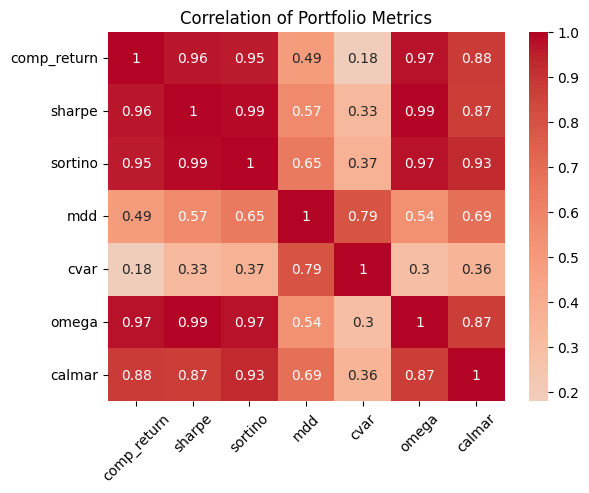


comp_return is highly correlated with:
  sharpe: 0.964
  sortino: 0.954
  omega: 0.969
  calmar: 0.876

sharpe is highly correlated with:
  comp_return: 0.964
  sortino: 0.986
  omega: 0.994
  calmar: 0.872

sortino is highly correlated with:
  comp_return: 0.954
  sharpe: 0.986
  omega: 0.972
  calmar: 0.927

mdd is highly correlated with:
  cvar: 0.789

cvar is highly correlated with:
  mdd: 0.789

omega is highly correlated with:
  comp_return: 0.969
  sharpe: 0.994
  sortino: 0.972
  calmar: 0.868

calmar is highly correlated with:
  comp_return: 0.876
  sharpe: 0.872
  sortino: 0.927
  omega: 0.868


In [12]:
corr = all_overall_perfs.corr()

plot_corr(corr, title='Correlation of Portfolio Metrics')

high_corr_with_each_metric(corr, threshold=0.75)

Most metrics are highly correlated with each other, with omega and sharpe showing high correlation with most of the other metrics. We can choose Sharpe, Calmar and maybe even CVaR to be our main metrics. CVaR and MDD are highly correlated so we can have one of them to add in loss like or bad scenarios.

##### Principle Component Analysis:

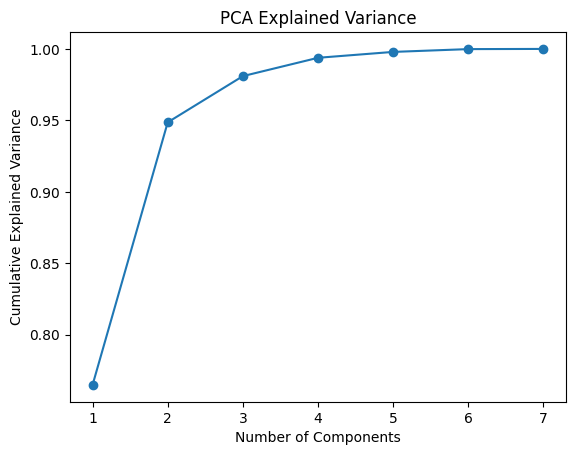

In [13]:
scaler = StandardScaler()
scaled_perf = scaler.fit_transform(all_overall_perfs)

pca = PCA()
pca.fit(scaled_perf)

# Explained variance ratio
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.plot(range(1, len(explained)+1), cumulative, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

The first principle component explains ~ 25% of the variance. At 6 princple components, almost 100% of the variance is explained.

In [14]:
loadings = pca.components_.T 

def print_important_metrics(loadings, metrics, n_components=5, top_n=3):
    for i in range(n_components):
        # Get loadings for component i
        comp_loadings = loadings[:, i]
        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(comp_loadings))[::-1]
        print(f"\nPrincipal Component {i+1} (explained variance: {pca.explained_variance_ratio_[i]:.3f})")
        for j in range(top_n):
            idx = sorted_idx[j]
            print(f"  {metrics[idx]}: {comp_loadings[idx]:.3f}")

# Example:
print_important_metrics(loadings, all_overall_perfs.columns, n_components=6, top_n=3)


Principal Component 1 (explained variance: 0.765)
  sortino: 0.427
  sharpe: 0.419
  omega: 0.415

Principal Component 2 (explained variance: 0.184)
  cvar: 0.743
  mdd: 0.542
  comp_return: -0.280

Principal Component 3 (explained variance: 0.032)
  calmar: 0.582
  cvar: -0.491
  mdd: 0.486

Principal Component 4 (explained variance: 0.013)
  calmar: 0.669
  mdd: -0.601
  cvar: 0.363

Principal Component 5 (explained variance: 0.004)
  comp_return: 0.833
  sortino: -0.380
  sharpe: -0.331

Principal Component 6 (explained variance: 0.002)
  omega: 0.693
  sortino: -0.666
  comp_return: -0.188


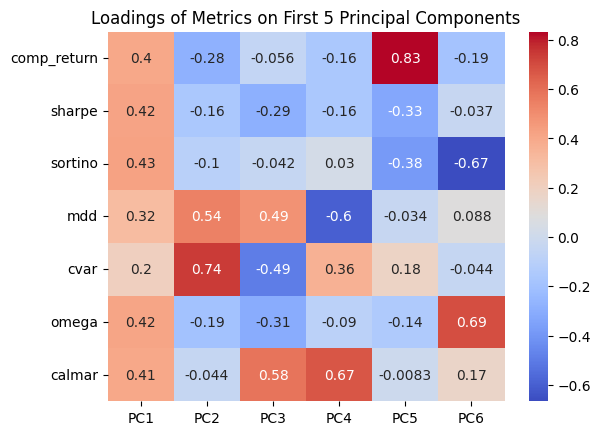

In [15]:
plt.figure()
sns.heatmap(loadings[:, :6], annot=True, cmap='coolwarm', 
            xticklabels=[f'PC{i+1}' for i in range(6)],
            yticklabels=all_overall_perfs.columns)
plt.title('Loadings of Metrics on First 5 Principal Components')
plt.savefig('./pc_val_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

PC1 (explains 50.0% of variance) – High positive loadings on Sharpe (0.50), Omega (0.48), and Sortino (0.48).
- PC1 captures risk‑adjusted return (higher is better).
PC2 (explains 27.8% of variance) – High positive loading on CVaR (0.58) (which is undesirable) and negative loadings on Calmar (–0.46) and compounded return (–0.46) (both desirable).
- Higher PC2 indicates higher tail risk, lower drawdown‑adjusted return, and lower raw return – i.e., worse overall.
- To align with “higher is better”, we invert PC2 (use –PC2). Then –PC2 represents low tail risk, high Calmar, and high raw return.
PC3 (explains 12.9% of variance) – High positive loading on compounded return (0.76) but also positive on CVaR (0.33) and negative on Calmar (–0.48). This component is ambiguous (higher raw return comes with higher tail risk and lower Calmar), so we do not use it for Pareto selection.
Thus, we construct a 2D Pareto frontier using PC1 (risk‑adjusted return) and –PC2 (low tail risk + high Calmar/return). Both dimensions are “higher is better”, providing a clear, interpretable trade‑off. This approach leverages the PCA results while avoiding the complexity of a third dimension.

For robustness, we also consider the original metrics Sharpe (primary), Calmar (drawdown control), and CVaR (tail risk) as a sanity check. However, the PC1 + –PC2 combination already captures the same information in a more balanced way.

##### Pareto Frontier with Top 2 Principle Components

In [16]:
# Transform the standardized data (already filtered to models only, no benchmarks)
pca_scores = pca.transform(scaled_perf)   # shape (n_models, n_components)

pc_df = pd.DataFrame({
    'PC1': pca_scores[:, 0],
    'PC2_inv': -pca_scores[:, 1]          # invert so higher is better
}, index=all_overall_perfs.index)

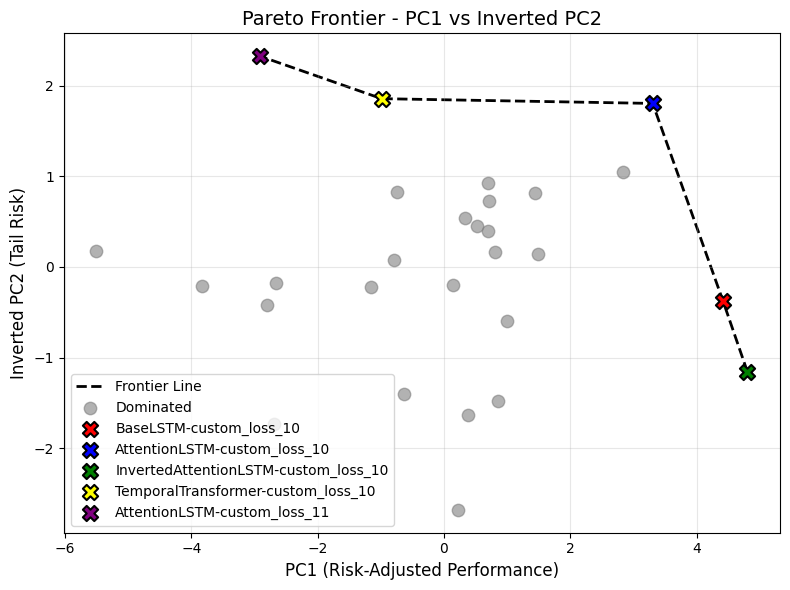

,PC1,PC2_inv,dominated
AttentionLSTM-custom_loss_11,-2.918011,2.330396,False
TemporalTransformer-custom_loss_10,-0.985755,1.859425,False
AttentionLSTM-custom_loss_10,3.305285,1.806807,False
BaseLSTM-custom_loss_10,4.420204,-0.379728,False
InvertedAttentionLSTM-custom_loss_10,4.805085,-1.159296,False


In [19]:
pc_df['dominated'] = pareto_dominance(pc_df, ['PC1', 'PC2_inv'])
frontier = pc_df[~pc_df['dominated']].copy()

frontier_sorted = frontier.sort_values('PC1')

plot_2d_pareto_diff_colrs(
    df=pc_df,
    x_col='PC1',
    y_col='PC2_inv',
    dominated_col='dominated',
    title='Pareto Frontier - PC1 vs Inverted PC2',
    xlabel='PC1 (Risk-Adjusted Performance)',
    ylabel='Inverted PC2 (Tail Risk)',
    colormap=['red','blue','green', 'yellow', 'purple'],
    line_color='black',
    output_path='pc_val_pareto.png'
)

plt.show()
frontier_sorted

##### Pareto Frontier with 2 or 3 Metrics

In [21]:
fig = px.scatter_3d(
    all_overall_perfs,
    x='sharpe',
    y='comp_return',
    z='cvar',
    hover_name=all_overall_perfs.index,
    color='sharpe',                # color by Sharpe (or any metric)
    title='3D Performances Plot: Sharpe, Calmar, CVaR',
    labels={
        'sharpe': 'Sharpe Ratio',
        'compunded_return': 'Compounded Return',
        'cvar': 'CVaR (higher better)'
    }
)

# Update marker size and appearance
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

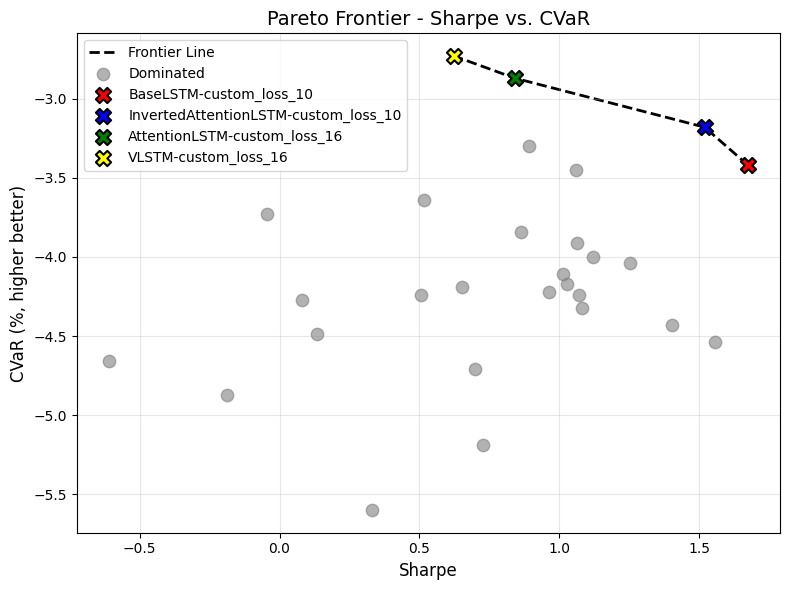

,comp_return,sharpe,sortino,mdd,cvar,omega,calmar,dominated
BaseLSTM-custom_loss_10,105.34,1.6740,2.3681,-19.08,-3.42,1.3379,2.4053,False
InvertedAttentionLSTM-custom_loss_10,91.27,1.5189,2.3667,-13.05,-3.18,1.3318,3.1082,False
AttentionLSTM-custom_loss_16,32.31,0.8410,1.1799,-30.74,-2.87,1.1597,0.5150,False
VLSTM-custom_loss_16,21.38,0.6236,0.8835,-20.60,-2.73,1.1288,0.5197,False


In [22]:
temp_perf = all_overall_perfs.copy()

temp_perf['dominated'] = pareto_dominance(temp_perf, ['sharpe', 'cvar'])

frontier_2d = temp_perf[~temp_perf['dominated']]

plot_2d_pareto_diff_colrs(
    df=temp_perf,
    x_col='sharpe',
    y_col='cvar',
    dominated_col='dominated',
    title='Pareto Frontier - Sharpe vs. CVaR',
    xlabel='Sharpe',
    ylabel='CVaR (%, higher better)',
    colormap=['red','blue','green', 'yellow'],
    line_color='black',
    output_path='val_pareto.png'
)

plt.show()
frontier_sorted = frontier_2d.sort_values('sharpe', ascending=False)
frontier_sorted

In [24]:
temp_perf = all_overall_perfs.copy()

cols = ['sharpe', 'comp_return', 'cvar']
temp_perf['dominated_3d'] = pareto_dominance(temp_perf, cols)

frontier_3d = temp_perf[~temp_perf['dominated_3d']]

fig = plot_3d_pareto(
    df=temp_perf,
    x_col='sharpe',
    y_col='comp_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier - Sharpe, Compounded Return, CVaR',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()

# Efficient frontier models vs Benchmarks
frontier_model_names = list(frontier_3d.index)
pd.concat(
    [frontier_3d.sort_values(by='sharpe', ascending=False), benchmarks_df],
    axis=0
)

,comp_return,sharpe,sortino,mdd,cvar,omega,calmar,dominated_3d
BaseLSTM-custom_loss_10,105.34,1.6740,2.3681,-19.08,-3.42,1.3379,2.4053,False
AttentionLSTM-custom_loss_10,132.13,1.5546,2.0459,-31.54,-4.54,1.3519,1.7631,False
InvertedAttentionLSTM-custom_loss_10,91.27,1.5189,2.3667,-13.05,-3.18,1.3318,3.1082,False
DeformTime-custom_loss_16,109.57,1.4018,1.9070,-26.87,-4.43,1.2876,1.7665,False
AttentionLSTM-custom_loss_16,32.31,0.8410,1.1799,-30.74,-2.87,1.1597,0.5150,False
VLSTM-custom_loss_16,21.38,0.6236,0.8835,-20.60,-2.73,1.1288,0.5197,False
Equal_Weight,48.90,0.9059,1.0343,-35.85,-4.23,1.2045,0.6484,NaN
S&P500,42.45,0.8341,0.9324,-33.93,-4.28,1.1902,0.6017,NaN


#### Daily Returns for the frontier models

In [25]:
processed_files = {
    'returns_val': Path(paths_config['processed_paths']['returns_val'])
}

processed_dfs = load_csv_files(processed_files, index_dt=True)

def extract_window_dates(returns_val, num_steps, out_size):
    out_wind_idxs = []
    for step in range(1, num_steps+1):
        current_start, current_end = calc_current_idxs(step, out_size)

        out_wind_idxs.append((current_start, current_end))
    
    out_win_date_cols = get_date_index_col(returns_val, out_wind_idxs)

    return out_win_date_cols


out_win_date_cols = extract_window_dates(processed_dfs['returns_val'], 8, 60)

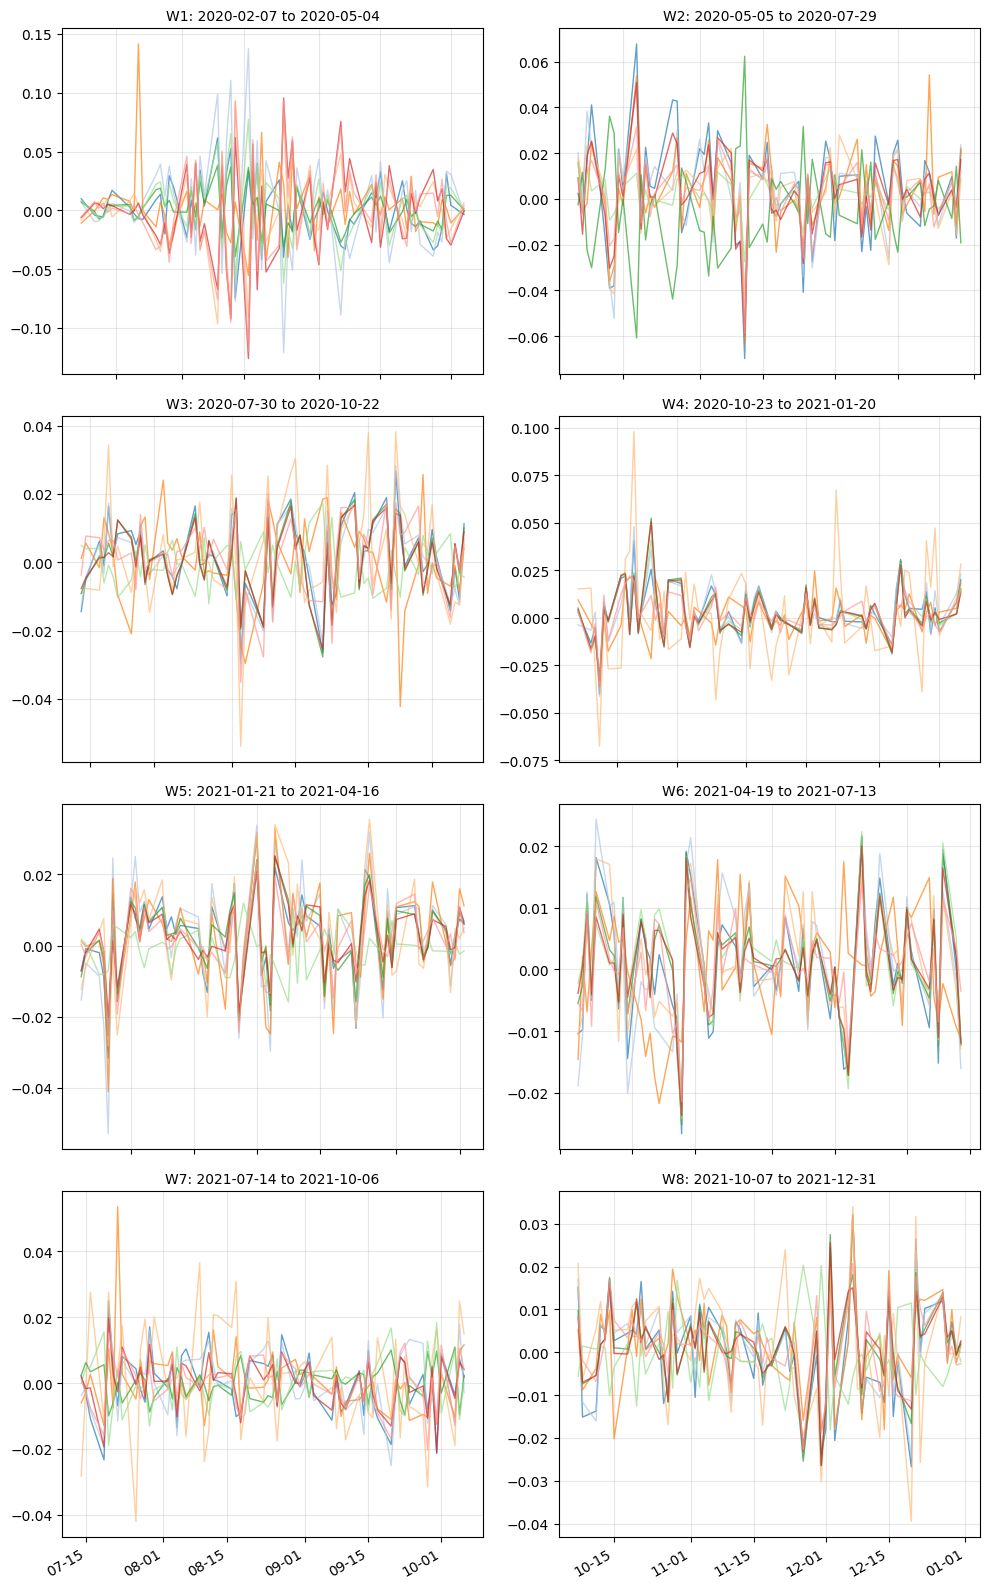

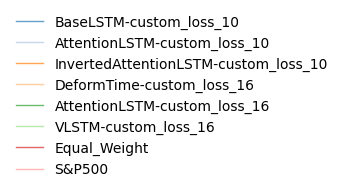

In [26]:
if all_daily_rets:    
    frontier_daily_rets = {
        k: all_daily_rets[k] for k in frontier_model_names if k in frontier_model_names
    }

    for bench in all_benches:
        bench_rets = all_daily_rets.get(bench)
        if bench_rets:
            frontier_daily_rets.update({bench: bench_rets})

    plot_windowed_comparison(
        all_daily_returns=frontier_daily_rets,
        window_dates=out_win_date_cols,
        windows_per_row=2,
        plot=True
    )
else:
    print('WARNING: No daily returns found.')

#### Training Loss Curves for best performing model loss combination

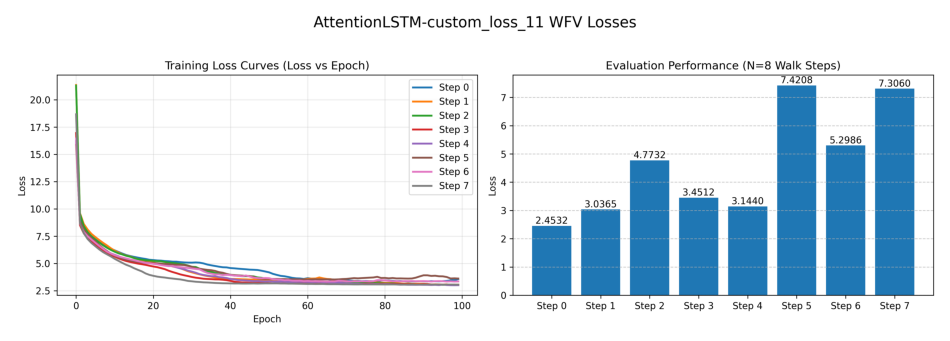

{'model': {'hidden_size': 32,
  'num_layers': 2,
  'nheads': 4,
  'dropout': 0.4468397974913796,
  'equal_prior': False,
  'allow_short': True},
 'optimizer': {'lr': 0.00047585440668587194,
  'weight_decay': 0.0003419290294464557},
 'train': {'train_batch_size': 64,
  'val_batch_size': 64,
  'clip_grad_norm': 0.5,
  'epochs': 100,
  'min_epochs': 0,
  'early_stopping': False,
  'early_stop_patience': 20,
  'early_stop_min_delta': 0.0001},
 'scheduler': {'factor': 0.5, 'patience': 10, 'min_lr': 1e-06},
 'loss': {'cvar_lambda': 1, 'risk_p_lambda': 0.001}}

In [27]:
def plot_train_curves(model_name):
    plt.figure(figsize=(12, 8))
    img = mpimg.imread(artifacts_paths['tuned_plots_dir'] / f'{model_name} WFV Losses.png')
    plt.imshow(img)
    plt.axis('off')  # hide axes
    plt.show()

model_name = 'AttentionLSTM-custom_loss_11'
plot_train_curves(model_name)
opti_hparams.get(model_name)

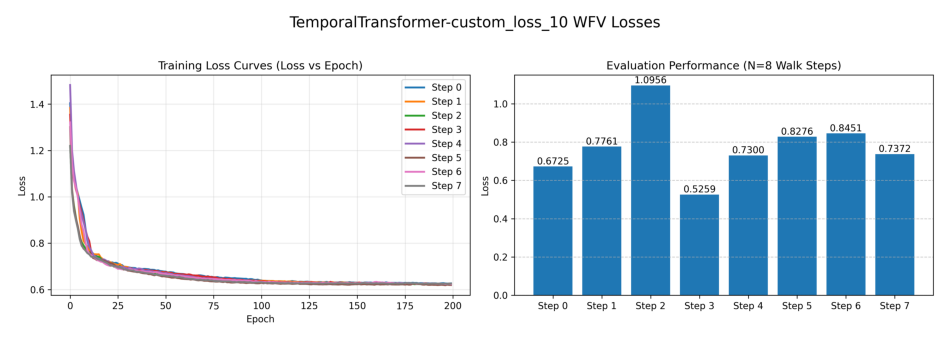

In [28]:
model_name = 'TemporalTransformer-custom_loss_10'
plot_train_curves(model_name)

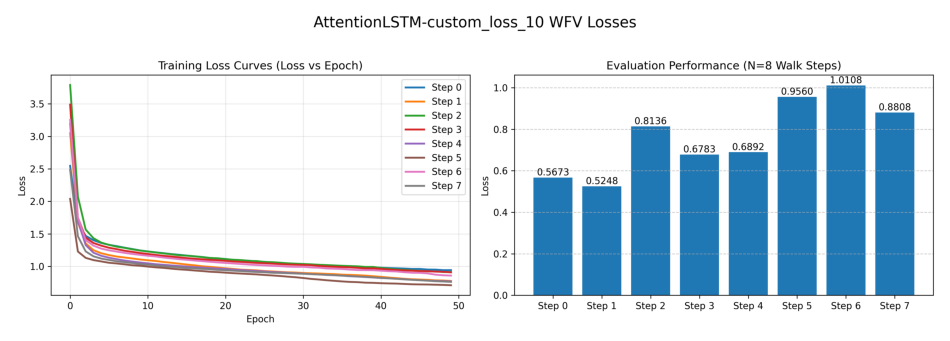

In [29]:
model_name = 'AttentionLSTM-custom_loss_10'
plot_train_curves(model_name)

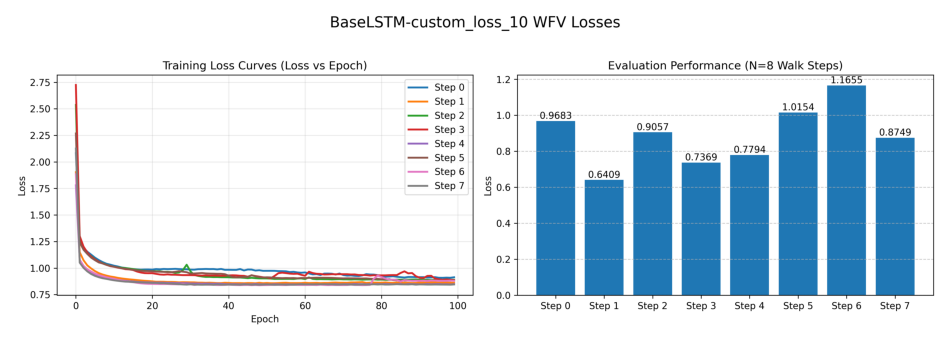

In [30]:
model_name = 'BaseLSTM-custom_loss_10'
plot_train_curves(model_name)

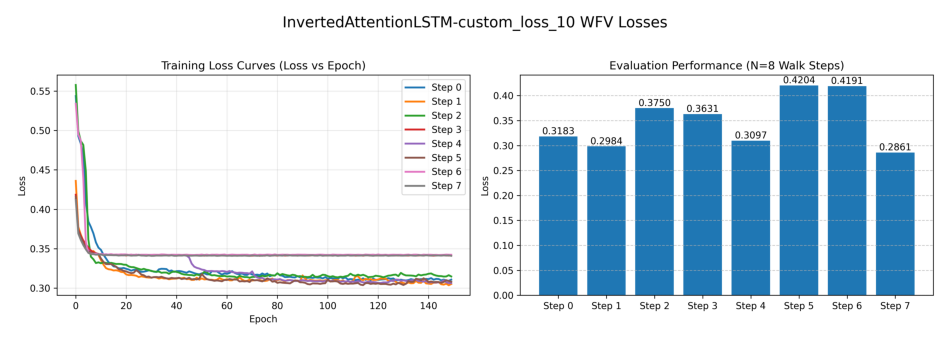

In [31]:
model_name = 'InvertedAttentionLSTM-custom_loss_10'
plot_train_curves(model_name)

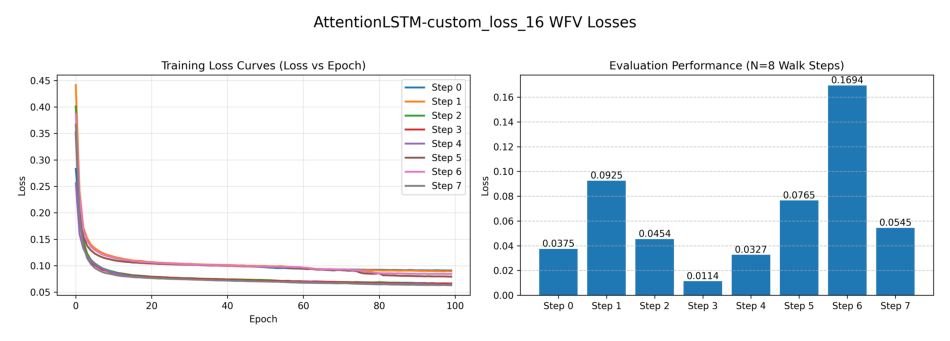

In [32]:
model_name = 'AttentionLSTM-custom_loss_16'
plot_train_curves(model_name)

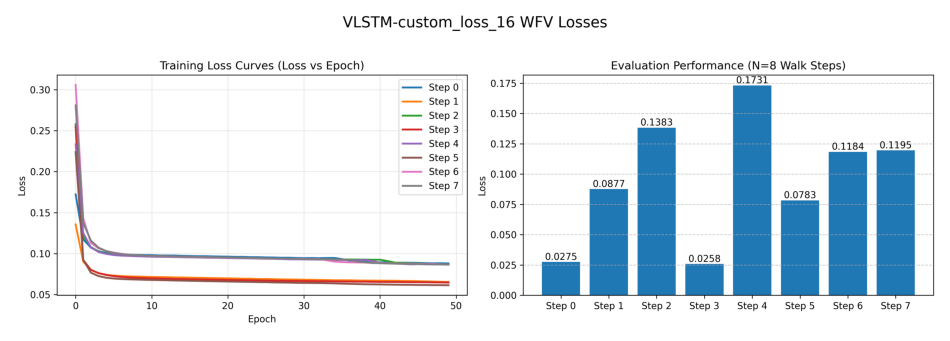

In [33]:
model_name = 'VLSTM-custom_loss_16'
plot_train_curves(model_name)